# Import & Setup

In [ ]:
# General purpose
import random
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# DL
import torch
import torch.nn.functional as F

# Classification task specific
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Data
from sklearn.model_selection import GridSearchCV, train_test_split
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
from train_config import BLIND_DATA_FILE, DATA_FILE

from shinobi_cv.config import MODELS_PATH

In [ ]:
SEED = 42

def set_seed(seed=42):
    # Python & NumPy
    random.seed(seed)
    np.random.seed(seed)
    
    # PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Multi-GPU config
    
    # Backend CUDA (CuDNN)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)


# Data

The dataset is small so there is no need to overcomplicate things. I can load it entirely in the RAM, therefore simple *pandas* DataFrame and file loading will do it. 

Preprocessing via *scikit-learn* is essential: data are collected already normalized to be in [-1,1] and balanced, thus the only step done here is the train/test/val split. 

In [3]:
df = pd.read_csv(DATA_FILE).to_numpy()

X, Y = df[:,:-1], df[:, -1]

# Split 70% training | 15% validation | 15% test
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=SEED)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, random_state=SEED)

print(f"Number of training feature = {len(x_train[0])}")
print(f"Number of classes to predict = {len(set(Y))}")
print(f"Number of training samples = {len(x_train)}")
print(f"Number of validation samples = {len(x_val)}")
print(f"Number of testing samples = {len(x_test)}")

Number of training feature = 126
Number of classes to predict = 6
Number of training samples = 692
Number of validation samples = 148
Number of testing samples = 149


# Experiment 1: Random Forest

In [4]:
grid_params = {
    "n_estimators" : [10, 100, 200, 300],
    "criterion" : ['gini', 'entropy'],
    "max_depth": [10, 20, 50, 100]
}

grid = GridSearchCV(
    estimator = RandomForestClassifier(),
    param_grid = grid_params,
    cv = 5
)

start = time.time()

grid.fit(x_train, y_train)

train_time = time.time() - start

print(f"Training finished after {(train_time)} seconds.")

Training finished after 53.294260025024414 seconds.


In [5]:
grid.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [6]:
grid.best_score_

np.float64(0.9927849025127724)

In [25]:
preds = grid.best_estimator_.predict(x_test)

In [27]:
preds.astype(np.int32)

array([0, 3, 1, 1, 3, 5, 2, 1, 2, 5, 2, 1, 2, 2, 0, 0, 4, 3, 0, 0, 1, 1,
       2, 3, 3, 5, 3, 2, 5, 3, 0, 1, 3, 0, 0, 1, 2, 1, 1, 2, 0, 4, 3, 3,
       1, 2, 3, 0, 5, 0, 3, 4, 5, 5, 4, 3, 4, 0, 1, 5, 5, 3, 5, 4, 4, 3,
       2, 5, 2, 2, 1, 3, 3, 1, 3, 5, 4, 1, 3, 4, 2, 4, 1, 5, 3, 4, 2, 3,
       4, 3, 2, 5, 5, 3, 2, 0, 5, 2, 0, 4, 4, 3, 1, 5, 0, 5, 0, 4, 2, 4,
       3, 0, 2, 1, 5, 4, 4, 5, 1, 0, 5, 4, 0, 3, 5, 2, 2, 5, 2, 5, 4, 5,
       1, 1, 1, 0, 2, 3, 1, 1, 0, 5, 4, 3, 2, 4, 1, 5, 1], dtype=int32)

In [8]:
print(confusion_matrix(y_test, preds))

[[21  0  0  0  0  0]
 [ 0 24  0  0  0  0]
 [ 0  0 25  0  0  0]
 [ 0  1  0 27  0  0]
 [ 0  1  0  1 22  0]
 [ 0  0  0  0  0 27]]


In [9]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        21
         1.0       0.92      1.00      0.96        24
         2.0       1.00      1.00      1.00        25
         3.0       0.96      0.96      0.96        28
         4.0       1.00      0.92      0.96        24
         5.0       1.00      1.00      1.00        27

    accuracy                           0.98       149
   macro avg       0.98      0.98      0.98       149
weighted avg       0.98      0.98      0.98       149



In [ ]:
# Blind test: data collected in a separate session, though same person, same environmant, different light and slighly more motion.

df2 = pd.read_csv(BLIND_DATA_FILE).to_numpy()

X2, Y2 = df2[:,:-1], df2[:, -1]

preds = grid.best_estimator_.predict(X2)
print(confusion_matrix(Y2, preds))
print(classification_report(Y2, preds))


[[ 5  0  5  0  0  2]
 [ 0 19  0  0  0  0]
 [ 1  0 10  0  0  0]
 [ 0  1  0  2 11  0]
 [ 0  5  0  3  4  0]
 [ 0  2  0  6  0 10]]
              precision    recall  f1-score   support

         0.0       0.83      0.42      0.56        12
         1.0       0.70      1.00      0.83        19
         2.0       0.67      0.91      0.77        11
         3.0       0.18      0.14      0.16        14
         4.0       0.27      0.33      0.30        12
         5.0       0.83      0.56      0.67        18

    accuracy                           0.58        86
   macro avg       0.58      0.56      0.55        86
weighted avg       0.60      0.58      0.57        86



In [23]:
# Save the object random forest
joblib.dump(grid.best_estimator_,  MODELS_PATH / "rf_model.pkl")

['/home/linuxriber/deep_learning_studio/PROJECTS/shinobi_cv/src/models/rf_model.pkl']

In [39]:
X2[0].shape

(126,)

In [ ]:
# Extract a single integer class value from a single row
grid.best_estimator_.predict(X2[0].reshape(1, -1)).astype(np.int32).item() # reshape for single sample prediction, then extract the integer

0

# Experiment 2: MLP

In [12]:
# Check for gpu availability
if torch.cuda.is_available(): 
    print(torch.cuda.get_device_properties())
else: 
    print("GPU not available/visible.")
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_CudaDeviceProperties(name='NVIDIA GeForce RTX 3050 Ti Laptop GPU', major=8, minor=6, total_memory=4095MB, multi_processor_count=20, uuid=8cf9bea4-327e-c843-a5f5-ee2d5112398f, pci_bus_id=1, pci_device_id=0, pci_domain_id=0, L2_cache_size=2MB)


## Data preparation

In [14]:
# nomenclature: _t is for tensor version
x_train_t, x_val_t, x_test_t, y_train_t, y_val_t, y_test_t =    torch.tensor(x_train, dtype=torch.float32), torch.tensor(x_val, dtype=torch.float32), \
                                                                torch.tensor(x_test, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long), \
                                                                torch.tensor(y_val, dtype=torch.long), torch.tensor(y_test, dtype=torch.long)

In [15]:
BATCH_SIZE = 32

train_ds = TensorDataset(x_train_t, y_train_t) 
val_ds = TensorDataset(x_val_t, y_val_t)
test_ds = TensorDataset(x_test_t, y_test_t)

train_data_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, num_workers=0, shuffle=True)    # num_workers = 0 to avoid overhead with such a small dataset
val_data_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0)
test_data_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0)

## Network

In [16]:
class HandSignMLP(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=126, out_features=64), 
            nn.ReLU(),
            nn.Linear(in_features=64, out_features=6) # TODO: QUANDO è COMPLETO IL DATASET QUI DEVI METTERCI 12; HARD CODED CONCESSO PERCHé SERVE ESATTAMENTE A QUESTO OBIETTIVO
        )

    def forward(self, x):
        return self.net(x)

## Training

In [17]:
EPOCHS = 10

model = HandSignMLP()
model = model.to(device)
optimizer = Adam(model.parameters(), lr=3e-4)
loss_history = []

In [18]:
print("Params:", f"{sum(p.numel() for p in model.parameters()):,}") # Expected: (126*64+64) + (64*12+12) = 8908

Params: 8,518


Iter #0 --- Training loss = 1.717781738801436
Iter #0 --- Validation loss = 1.646622610092163
Iter #1 --- Training loss = 1.5736181248318066
Iter #1 --- Validation loss = 1.5074700117111206
Iter #2 --- Training loss = 1.4288881637833335
Iter #2 --- Validation loss = 1.3614629983901978
Iter #3 --- Training loss = 1.2806799682703884
Iter #3 --- Validation loss = 1.219972348213196
Iter #4 --- Training loss = 1.143089619549838
Iter #4 --- Validation loss = 1.0891252279281616
Iter #5 --- Training loss = 1.0172554146159778
Iter #5 --- Validation loss = 0.9712689399719239
Iter #6 --- Training loss = 0.902244280685078
Iter #6 --- Validation loss = 0.8672470331192017
Iter #7 --- Training loss = 0.8009571839462627
Iter #7 --- Validation loss = 0.7766231298446655
Iter #8 --- Training loss = 0.7138365100730549
Iter #8 --- Validation loss = 0.699722421169281
Iter #9 --- Training loss = 0.6375494165854021
Iter #9 --- Validation loss = 0.6290631771087647


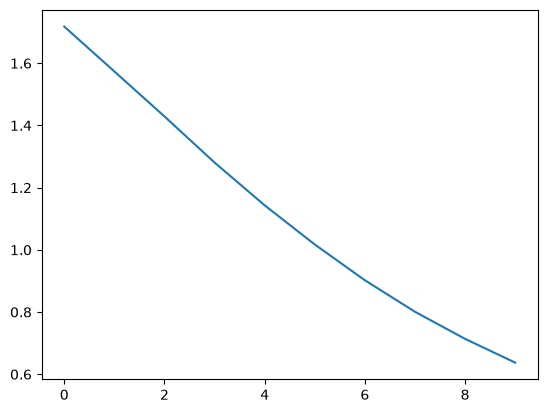

In [19]:
# Training loop
for i in range(EPOCHS): 

    # Set training mode
    model.train()

    train_loss = 0.0

    # Process per batch (_b: "batch" just to not confuse with other similar names)
    for x_b, y_b in train_data_loader:

        # Move data to GPU if available
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        # ====================================================
        # Zero out gradients
        optimizer.zero_grad()

        # Forward step
        logits = model(x_b)

        # Compute loss: for classification use CE
        loss = F.cross_entropy(logits, y_b)
        train_loss += loss.item()   # Only the number! THIS MUST NOT BE HOOKED TO THE COMPUTATIONAL GRAPH --> RAM OOM RISK 

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()
        # ====================================================

    # Visual information
    print(f"Iter #{i} --- Training loss = {train_loss / len(train_data_loader)}")

    # ====== Validation =========
    # Set the model to validation mode 
    model.eval()

    # Do not trace gradients during validation
    with torch.no_grad():
        val_loss = 0.0
        for x_v_b, y_v_b in val_data_loader:
            x_v_b = x_v_b.to(device)
            y_v_b = y_v_b.to(device)
            val_loss += F.cross_entropy(model(x_v_b), y_v_b).item()

    print(f"Iter #{i} --- Validation loss = {val_loss / len(val_data_loader)}")

    loss_history.append(train_loss / len(train_data_loader))

plt.plot(loss_history)


In [20]:
# Test 
model = model.to("cpu")
model.eval()
with torch.no_grad():
    logits = model(x_test_t)
    preds = torch.argmax(logits, axis=1).numpy()
print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))

[[21  0  0  0  0  0]
 [ 0 23  0  0  1  0]
 [ 0  0 25  0  0  0]
 [ 0  0  0 28  0  0]
 [ 0  0  0  0 24  0]
 [ 0  0  0  0  0 27]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        21
         1.0       1.00      0.96      0.98        24
         2.0       1.00      1.00      1.00        25
         3.0       1.00      1.00      1.00        28
         4.0       0.96      1.00      0.98        24
         5.0       1.00      1.00      1.00        27

    accuracy                           0.99       149
   macro avg       0.99      0.99      0.99       149
weighted avg       0.99      0.99      0.99       149



In [28]:
# Blind test for the neural network
blind_x_test_t = torch.Tensor(X2)
model.eval()
with torch.no_grad():
    logits = model(blind_x_test_t)
    preds = torch.argmax(logits, axis=1).numpy()
print(confusion_matrix(Y2, preds))
print(classification_report(Y2, preds))

[[11  1  0  0  0  0]
 [ 1 11  0  0  7  0]
 [ 0  0 11  0  0  0]
 [ 0  0  0 13  1  0]
 [ 0  2  0  0 10  0]
 [ 0  0  0  6  0 12]]
              precision    recall  f1-score   support

         0.0       0.92      0.92      0.92        12
         1.0       0.79      0.58      0.67        19
         2.0       1.00      1.00      1.00        11
         3.0       0.68      0.93      0.79        14
         4.0       0.56      0.83      0.67        12
         5.0       1.00      0.67      0.80        18

    accuracy                           0.79        86
   macro avg       0.82      0.82      0.81        86
weighted avg       0.83      0.79      0.79        86



In [31]:
preds

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 1, 1, 1, 4, 4, 1, 4, 4, 4,
       4, 1, 1, 1, 1, 1, 0, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3,
       3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       1, 1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 3, 3, 3, 3, 3, 3, 5, 5])

In [36]:
# Extract the integer value of the class from a single prediciton
type(torch.argmax(torch.zeros(12)).item())

int

In [ ]:
# Saving WEIGHTS only
torch.save(model.state_dict(), MODELS_PATH / "mlp_model.pth")

# Comparison & Conclusion 

1. Data collection can and should be refined. Test using a blind dataset reveled a deep weakness of the Random forest.

2. Withouth manipulating futher the data, the neural network shows better performance. 
3. Increasing the number of epochs worsen performance (overfitting). 

# Further Experiment: GNN

See the file *research/gnn_experiment.ipynb*. 